# Background Figures
---
This notebook generates the "background" figures from the condensed dataset. The figures generated are:
1. Parameter-space histograms
2. Tau ($\tau$) distribution
3. Reionization histories
4. Single reionization history, kSZ map, and rescaled angular power spectrum ($D_\ell$)
5. Stacked reionization history, kSZ map, and rescaled angular power spectrum ($D_\ell$)

More information about the package can be found here: [Documentation](https://reionemu.org/)

## Imports

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import h5py
import numpy as np
import pandas as pd

## Paths

In [2]:
from config import H5_PATH, FIG_DIR, EXPERIMENT_NAME, make_dirs, param_order, param_labels

make_dirs()

## Simulation Output

In [3]:
with h5py.File(H5_PATH, "r") as h5f:
    print("Simulation 1")
    print("Parameters:\n", list(h5f["sims"]["sim1"]["params"]))
    print(f"\t zmean_zre: {h5f["sims"]["sim1"]["params"]["zmean_zre"][()]}")
    print(f"\t alpha_zre: {h5f["sims"]["sim1"]["params"]["alpha_zre"][()]}")
    print(f"\t kb_zre: {h5f["sims"]["sim1"]["params"]["kb_zre"][()]}")
    print(f"\t b0_zre: {h5f["sims"]["sim1"]["params"]["b0_zre"][()]}")
    
    print("Output:\n", list(h5f["sims"]["sim1"]["output"]))
    print(f"\t ksz_map Shape: {h5f['sims']['sim1']['output']['ksz_map'].shape}")
    print(f"\t theta_max_ksz: {h5f['sims']['sim1']['output']['theta_max_ksz'][()]} \t Degrees: {np.degrees(h5f['sims']['sim1']['output']['theta_max_ksz'][()])}")
    print(f"\t Tcmb0: {h5f['sims']['sim1']['output']['Tcmb0'][()]}")
    print(f"\t Tau: {h5f['sims']['sim1']['output']['tau'][()]}")
    print(f"\t zval_list Shape: {h5f['sims']['sim1']['output']['zval_list'].shape}")
    print(f"\t xmval_list Shape: {h5f['sims']['sim1']['output']['xmval_list'].shape}")
    print(f"\t pk_tt Shape: {h5f['sims']['sim1']['output']['pk_tt'].shape}")
    
    print("Cl:\n", list(h5f["sims"]["sim1"]["cl"]))
    print(f"\t cl_ksz: {h5f['sims']['sim1']['cl']['cl_ksz'][()]} \t Shape: {h5f['sims']['sim1']['cl']['cl_ksz'].shape}")
    print(f"\t dl_ksz: {h5f['sims']['sim1']['cl']['dl_ksz'][()]} \t Shape: {h5f['sims']['sim1']['cl']['dl_ksz'].shape}")
    print(f"\t ell: {h5f['sims']['sim1']['cl']['ell'][()]} \t Shape: {h5f['sims']['sim1']['cl']['ell'].shape}")

Simulation 1
Parameters:
 ['alpha_zre', 'b0_zre', 'kb_zre', 'zmean_zre']
	 zmean_zre: 8.88764818819783
	 alpha_zre: 0.4329503243946754
	 kb_zre: 0.1020456445037486
	 b0_zre: 0.24680639792154205
Output:
 ['Tcmb0', 'ksz_map', 'pk_tt', 'tau', 'theta_max_ksz', 'xmval_list', 'zval_list']
	 ksz_map Shape: (1024, 1024)
	 theta_max_ksz: 0.2843331859916941 	 Degrees: 16.291091532832333
	 Tcmb0: 2.7255
	 Tau: 0.0670870825453519
	 zval_list Shape: (26,)
	 xmval_list Shape: (26,)
	 pk_tt Shape: (26, 1024, 3)
Cl:
 ['cl_ksz', 'dcl', 'dl_ksz', 'ell']
	 cl_ksz: [1.33404460e-06 2.37077920e-07 7.04054364e-08 2.90737632e-08
 1.69774180e-08] 	 Shape: (5,)
	 dl_ksz: [0.87839689 0.63239574 0.42434385 0.31217971 0.28519583] 	 Shape: (5,)
	 ell: [ 2033.49633959  4093.41528716  6153.33423472  8213.25318229
 10273.17212985] 	 Shape: (5,)


## Parameter-Space Sampling

In [4]:
rows = []

with h5py.File(H5_PATH, "r") as h5f:
    sims = h5f["sims"]

    sim_names = sorted(
        sims.keys(),
        key=lambda s: int(s[3:]) if s.startswith("sim") and s[3:].isdigit() else s,
    )

    for name in sim_names:
        g = sims[name]
        rows.append(
            {
                "sim": name,
                "sim_id": int(name[3:]),
                "alpha_zre": float(g["params/alpha_zre"][()]),
                "kb_zre": float(g["params/kb_zre"][()]),
                "zmean_zre": float(g["params/zmean_zre"][()]),
                "b0_zre": float(g["params/b0_zre"][()]),
                "tau": float(g["output/tau"][()]),
            }
        )

df = pd.DataFrame(rows)

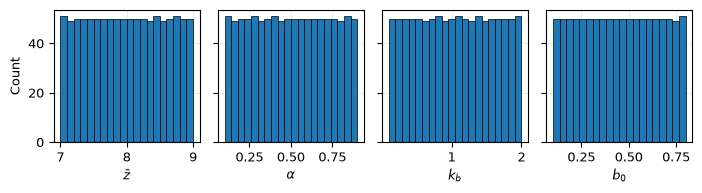

In [5]:
params = param_order

labels = dict(zip(param_order, param_labels))

fig, axes = plt.subplots(1, 4, figsize=(7.1, 2.0), sharey=True)

for ax, param in zip(axes, params):
    ax.hist(df[param], bins=20, color='tab:blue', edgecolor='black', alpha=1.0, linewidth=0.5)
    
    ax.set_xlabel(labels[param])
    
    if ax == axes[0]:
        ax.set_ylabel("Count")
        
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()

fig.savefig(FIG_DIR / f"parameter_histograms_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Tau ($\tau$) Distribution

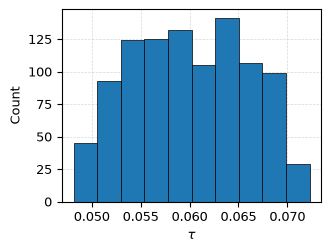

Mean: 0.0600 	 STD: 0.0058


In [6]:
fig, ax = plt.subplots()

ax.hist(df["tau"], bins=10, color='tab:blue', edgecolor="black", alpha=1.0, linewidth=0.5)

ax.set_xlabel(r"$\tau$")
ax.set_ylabel("Count")

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

fig.savefig(
    FIG_DIR / f"tau_distribution_{EXPERIMENT_NAME}.pdf",
    format="pdf", 
    bbox_inches="tight"
)

plt.show()

print(f"Mean: {df["tau"].mean():.4f} \t STD: {df["tau"].std():.4f}")

## Reionization Histories

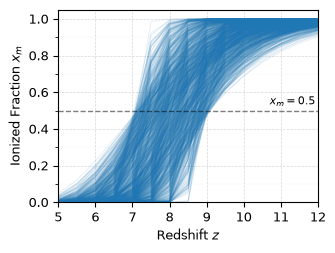

In [7]:
fig, ax = plt.subplots()

with h5py.File(H5_PATH, "r") as h5f:
    sims = h5f["sims"]
    for sim in sim_names:
        z = np.array(h5f[f"sims/{sim}/output/zval_list"][()], dtype=float)
        x = np.array(h5f[f"sims/{sim}/output/xmval_list"][()], dtype=float)
        z_order = np.argsort(z)
        z, x = z[z_order], x[z_order]
        
        ax.plot(z, x, color='tab:blue', lw=0.8, alpha=0.1)

ax.axhline(0.5, color="black", linestyle="--", lw=1.0, alpha=0.5)

ax.text(10.7, 0.53, r"$x_m = 0.5$", fontsize=8)

ax.set_xlabel("Redshift $z$")
ax.set_ylabel("Ionized Fraction $x_m$")

ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

ax.set_axisbelow(True)
ax.grid(True, which="major", linestyle='--', linewidth=0.5, alpha=0.5)
ax.grid(True, which="minor", linestyle=':', linewidth=0.3, alpha=0.3)

ax.set_xlim(5, 12)
ax.set_ylim(0, 1.05)

fig.savefig(
    FIG_DIR / f"reionization_histories_{EXPERIMENT_NAME}.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()

## Single Sim: Reionization History, kSZ Map, and Rescaled Angular Power Spectrum ($D_\ell$)

In [8]:
SIM_ID_1 = 100
SIM_ID_2 = 900

In [9]:
def load_sim(sim_id):
    """Read the arrays needed for the per-simulation panels."""
    with h5py.File(H5_PATH, "r") as f:
        g = f["sims"][f"sim{sim_id}"]
        return {
            "ksz_map": g["output"]["ksz_map"][()],
            "ell": g["cl"]["ell"][()],
            "dl": g["cl"]["dl_ksz"][()],
            "theta_max_ksz": g["output"]["theta_max_ksz"][()],
            "tcmb": float(g["output"]["Tcmb0"][()]),
            "z": np.array(g["output"]["zval_list"][()], dtype=float),
            "x": np.array(g["output"]["xmval_list"][()], dtype=float),
        }


def plot_sim_panels(fig, axes, sim_id, fs, ms, mew):
    """
    Draw the ionization history, kSZ map, and D_ell into three axes.

    Returns (z50, dz) where dz is the 25-75% ionized duration.
    """
    sim = load_sim(sim_id)

    # Sorted by redshift for plotting
    order = np.argsort(sim["z"])
    z, x = sim["z"][order], sim["x"][order]

    # Sorted by ionized fraction for interpolation: np.interp requires an
    # increasing xp, and x decreases as z increases
    interp_order = np.argsort(x)
    x_interp = x[interp_order]
    z_interp = z[interp_order]

    # Reionization milestones (interpolated from the data)
    z50 = np.interp(0.50, x_interp, z_interp)
    z25 = np.interp(0.25, x_interp, z_interp)
    z75 = np.interp(0.75, x_interp, z_interp)

    # Ionization History
    axes[0].plot(z, x, lw=2, label=f"sim{sim_id}")

    # 50% ionization
    axes[0].axvline(z50, color="red", ls="--", lw=1.0, alpha=0.6)
    axes[0].plot(z50, 0.50, marker="o", ms=ms, color="red", ls="none", zorder=3)

    # Duration from 25% to 75% ionized
    axes[0].axvline(z25, color="green", ls=":", lw=1.0, alpha=0.6)
    axes[0].axvline(z75, color="green", ls=":", lw=1.0, alpha=0.6)
    axes[0].plot(
        [z25, z75],
        [0.25, 0.75],
        marker="x",
        ms=ms,
        mew=mew,
        color="green",
        ls="none",
        zorder=3,
    )

    axes[0].set_xlim(5, 12)
    axes[0].set_ylim(0, 1.05)
    axes[0].yaxis.set_major_locator(MultipleLocator(0.1))

    axes[0].set_xlabel("Redshift", fontsize=fs)
    axes[0].set_ylabel("Mean Ionized Fraction", fontsize=fs)
    axes[0].legend(frameon=False, fontsize=fs - 2)
    axes[0].tick_params(labelsize=fs - 2)

    # kSZ Map
    rescaled_map = sim["ksz_map"] * sim["tcmb"] * 1e6

    tmax = np.amax(rescaled_map)
    tmin = np.amin(rescaled_map)
    textreme = max(tmax, np.abs(tmin))

    theta_max_deg = np.rad2deg(sim["theta_max_ksz"])

    extent = [
        -theta_max_deg / 2,
         theta_max_deg / 2,
        -theta_max_deg / 2,
         theta_max_deg / 2,
    ]

    im = axes[1].imshow(
        rescaled_map,
        cmap="RdBu",
        vmin=-textreme,
        vmax=textreme,
        extent=extent,
        origin="lower",
        rasterized=True,
    )

    cb = fig.colorbar(im, ax=axes[1])
    cb.set_label(r"$\Delta T$ [$\mu \mathrm{K}$]", fontsize=fs)
    cb.ax.tick_params(labelsize=fs - 2)

    axes[1].set_xlabel(r"$\theta_x$ [deg]", fontsize=fs)
    axes[1].set_ylabel(r"$\theta_y$ [deg]", fontsize=fs)
    axes[1].tick_params(labelsize=fs - 2)

    # Angular Power Spectrum
    axes[2].plot(
        sim["ell"], sim["dl"], marker="o", color="dodgerblue", lw=1.8, label=r"$D_\ell$"
    )
    axes[2].set_xlabel(r"$\ell$", fontsize=fs)
    axes[2].set_ylabel(
        r"$D_\ell = \ell(\ell + 1)C_{\ell} / 2\pi$ [$\mu \mathrm{K}^2$]",
        fontsize=fs,
    )
    axes[2].grid(True, which="both", alpha=0.3)
    axes[2].legend(frameon=False, fontsize=fs - 2)
    axes[2].tick_params(labelsize=fs - 2)

    return z50, abs(z75 - z25)

### SIM_ID_1

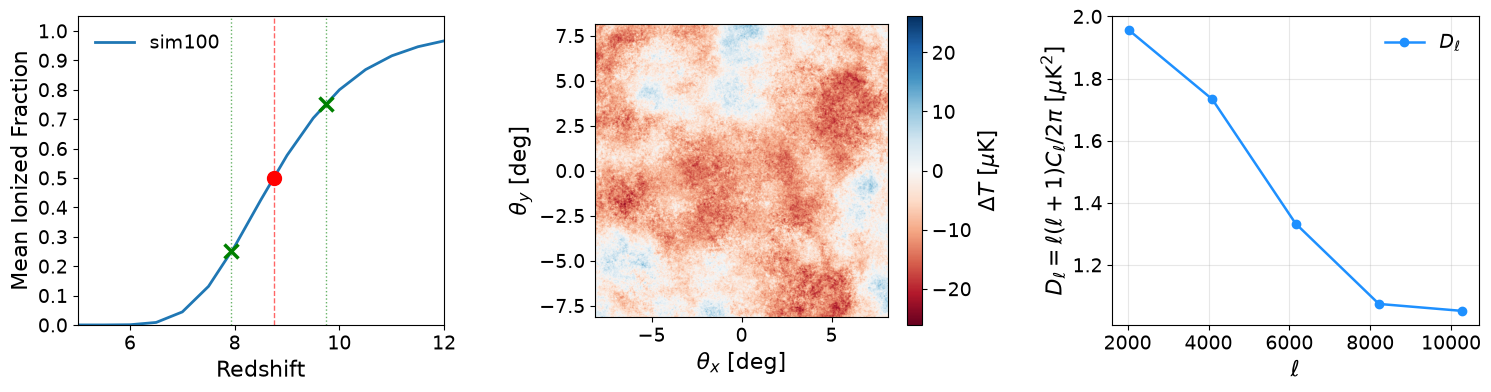

sim100: z50 = 8.75, dz(25-75) = 1.80


In [10]:
FS = 16

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

z50, dz = plot_sim_panels(fig, ax, SIM_ID_1, fs=FS, ms=10, mew=2.5)

fig.tight_layout(w_pad=3.0)
fig.savefig(
    FIG_DIR / f"ksz_map_spectrum_history_sim{SIM_ID_1}_{EXPERIMENT_NAME}.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()

print(f"sim{SIM_ID_1}: z50 = {z50:.2f}, dz(25-75) = {dz:.2f}")

### SIM_ID_2

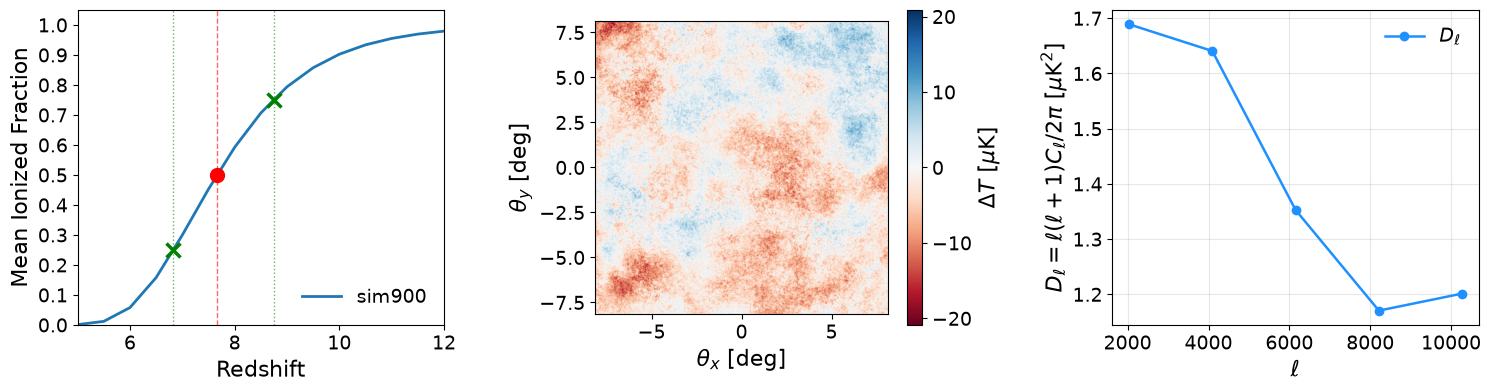

sim900: z50 = 7.67, dz(25-75) = 1.92


In [11]:
FS = 16

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

z50, dz = plot_sim_panels(fig, ax, SIM_ID_2, fs=FS, ms=10, mew=2.5)

fig.tight_layout(w_pad=3.0)
fig.savefig(
    FIG_DIR / f"ksz_map_spectrum_history_sim{SIM_ID_2}_{EXPERIMENT_NAME}.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()

print(f"sim{SIM_ID_2}: z50 = {z50:.2f}, dz(25-75) = {dz:.2f}")

## Stacked Reionization History, kSZ Map, and Rescaled Angular Power Spectrum ($D_\ell$)

sim100: z50 = 8.75, dz(25-75) = 1.80
sim900: z50 = 7.67, dz(25-75) = 1.92


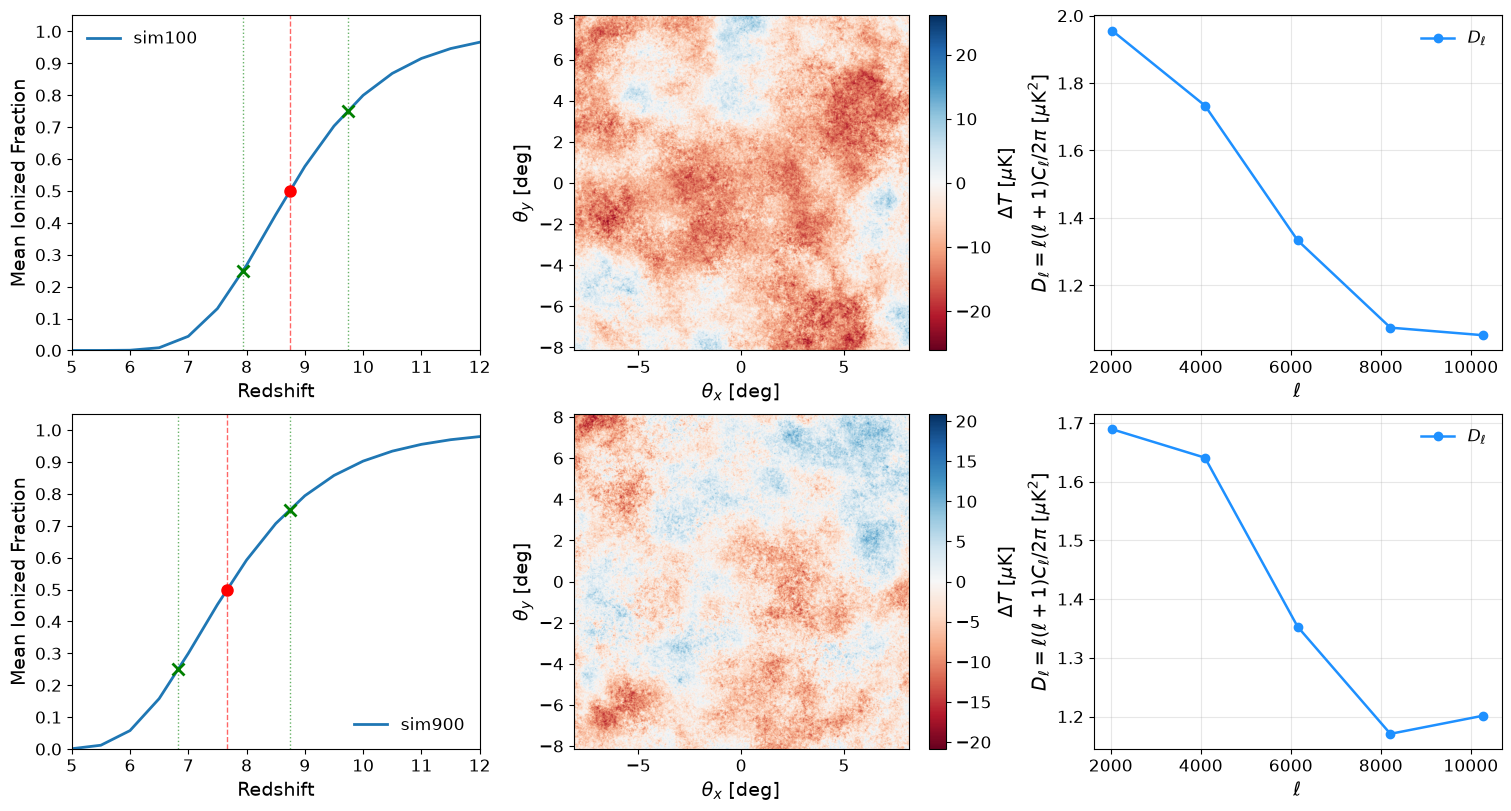

In [12]:
FS = 14

sim_ids = [SIM_ID_1, SIM_ID_2]

fig, ax = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

for row, sim_id in enumerate(sim_ids):
    z50, dz = plot_sim_panels(fig, ax[row], sim_id, fs=FS, ms=8, mew=2.0)
    print(f"sim{sim_id}: z50 = {z50:.2f}, dz(25-75) = {dz:.2f}")

fig.savefig(
    FIG_DIR / f"ksz_map_spectrum_history_stacked_sim{SIM_ID_1}_sim{SIM_ID_2}_{EXPERIMENT_NAME}.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()